# 15 · Boundary-value problems: heat transfer in a fin

**Problem.** A pin fin (an aluminium rod, 5 mm diameter, 50 mm long) cools a device whose surface is at
100 °C, in air at 20 °C with $h$ = 25 W/(m²·K). How does the temperature vary along the fin, and how
much heat does it remove? The energy balance gives
$$\frac{d^2T}{dx^2} = m^2\,(T - T_\infty),\qquad m^2 = \frac{hP}{kA} = \frac{4h}{kD},$$
with $T(0) = T_b$ at the base and convection at the tip, $-k\,T'(L) = h\,(T(L) - T_\infty)$.
Unlike notebook 11, conditions are given at **both ends**: a *boundary-value* problem.

**What you will learn**

- distinguish boundary-value from initial-value problems
- solve a BVP by shooting and by finite differences, including a convective boundary
- verify second-order accuracy against an exact solution
- solve a nonlinear BVP as a nonlinear system

**Before you start:** notebooks 02, 03, 06, 11 and 14; fin heat transfer (helpful)  ·  **Time:** about 60-75 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import bvp, nonlinear, odes

In [2]:
k, h, D, L, Tb, Tinf = 200.0, 25.0, 0.005, 0.05, 100.0, 20.0
m = np.sqrt(4 * h / (k * D))
Ac = np.pi * D**2 / 4
Bi = h / (m * k)
def T_exact(x):
    return Tinf + (Tb - Tinf) * (np.cosh(m*(L - x)) + Bi*np.sinh(m*(L - x))) / (np.cosh(m*L) + Bi*np.sinh(m*L))
q_exact = k * Ac * m * (Tb - Tinf) * (np.sinh(m*L) + Bi*np.cosh(m*L)) / (np.cosh(m*L) + Bi*np.sinh(m*L))
print(f"m = {m:.2f} 1/m, mL = {m*L:.2f};  exact heat rate {q_exact:.4f} W")

m = 10.00 1/m, mL = 0.50;  exact heat rate 1.4825 W


## Method 1: shooting
Turn the BVP into an initial-value problem by *guessing* the unknown slope $T'(0) = s$, integrate to the
tip (RK4, notebook 11), and measure how badly the tip condition is missed. Adjusting $s$ until the miss
is zero is a root-finding problem (notebook 02).

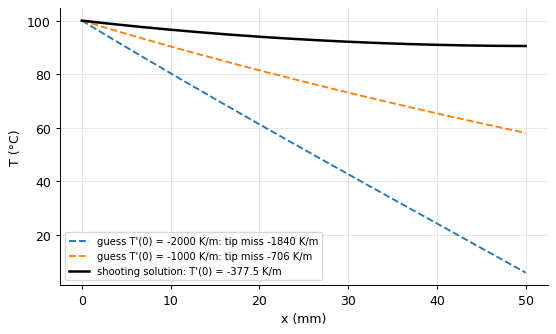

max error vs exact 3.8e-13 K;  heat rate -kA T'(0) = 1.4825 W


In [3]:
rhs = lambda x, u: [u[1], m**2 * (u[0] - Tinf)]
tip_miss = lambda T_end, dT_end: dT_end + h/k * (T_end - Tinf)     # zero when the tip condition holds
fig, ax = plt.subplots()
for s in (-2000, -1000):
    xg, u = odes.rk4(rhs, [Tb, s], 0, L, 200)
    ax.plot(xg*1000, u[:, 0], "--", label=f"guess T'(0) = {s} K/m: tip miss {tip_miss(u[-1, 0], u[-1, 1]):+.0f} K/m")
tip = ("robin", 1.0, h/k, h/k*Tinf)                                  # T' + (h/k) T = (h/k) T_inf
xs, Ts, dTs, s_star = bvp.shooting(lambda x, T, dT: m**2 * (T - Tinf), 0, L, Tb, tip, slopes=(-2000, -1000))
ax.plot(xs*1000, Ts, "k", lw=2, label=f"shooting solution: T'(0) = {s_star:.1f} K/m")
ax.set(xlabel="x (mm)", ylabel="T (°C)"); ax.legend(fontsize=8); plt.show()
print(f"max error vs exact {np.max(np.abs(Ts - T_exact(xs))):.1e} K;  heat rate -kA T'(0) = {-k*Ac*s_star:.4f} W")

## Inside the algorithm: why linear shooting needs only two shots
For a *linear* ODE the tip miss is a linear function of the guessed slope $s$. Two shots therefore
determine it exactly, and a straight line through them gives the correct slope - which is why the secant
iteration above converged in one step:

In [4]:
def miss(s):
    _, u = odes.rk4(rhs, [Tb, s], 0, L, 400)
    return tip_miss(u[-1, 0], u[-1, 1])

s0, s1 = -2000.0, -1000.0
m0, m1 = miss(s0), miss(s1)
s_linear = s0 - m0 * (s1 - s0) / (m1 - m0)            # where the straight line through both misses is zero
print(f"two shots + interpolation: T'(0) = {s_linear:.6f} K/m;  library: {s_star:.6f} K/m")

two shots + interpolation: T'(0) = -377.513035 K/m;  library: -377.513035 K/m


## Method 2: finite differences
Replace $T''$ by the central difference at every node (notebook 06). All the equations are then solved
**together** - a tridiagonal linear system (notebook 03). The convective tip uses a *ghost node* beyond
the end, which keeps second-order accuracy.

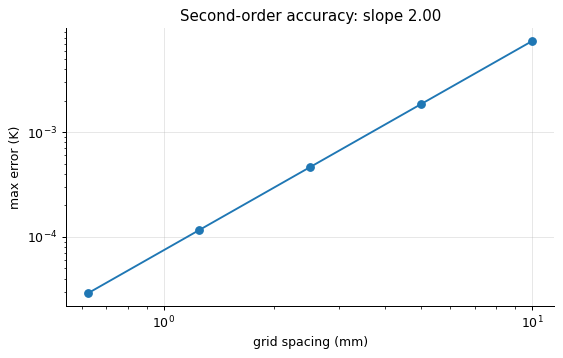

In [5]:
errs, ns = [], [5, 10, 20, 40, 80]
for n in ns:
    xf, Tf = bvp.finite_difference(lambda x: 0*x, lambda x: -m**2 + 0*x, lambda x: -m**2*Tinf + 0*x,
                                   0, L, n, ("dirichlet", Tb), tip)
    errs.append(np.max(np.abs(Tf - T_exact(xf))))
slope = np.polyfit(np.log(L/np.array(ns)), np.log(errs), 1)[0]
plt.loglog(L/np.array(ns)*1000, errs, "o-")
plt.xlabel("grid spacing (mm)"); plt.ylabel("max error (K)"); plt.title(f"Second-order accuracy: slope {slope:.2f}")
plt.show()

Shooting reuses an accurate ODE integrator and is easy to set up; finite differences handle many
unknowns and variable coefficients naturally, and extend to 2D and 3D (notebook 19).

## A nonlinear fin: adding radiation
A hot steel fin (400 °C base, $k$ = 40 W/(m·K), weak natural convection $h$ = 10 W/(m²·K), emissivity
0.9) also loses heat by radiation. With absolute temperatures the equation becomes nonlinear:
$$T'' = m^2 (T - T_\infty) + \frac{\varepsilon\sigma P}{kA}\,\left(T^4 - T_{sur}^4\right),$$
with an insulated tip for simplicity. Finite differences now give a **nonlinear system**, solved with
Newton's method (notebook 14):

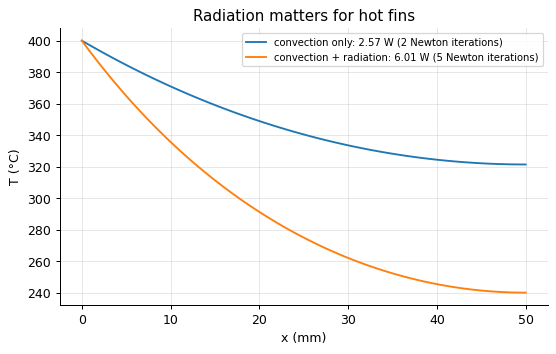

In [6]:
ks, hs, eps, sigma = 40.0, 10.0, 0.9, 5.670374419e-8
Tb2, Tinf2 = 673.15, 293.15
m2sq = 4 * hs / (ks * D)
rad = eps * sigma * 4 / (ks * D)
n = 100
xg = np.linspace(0, L, n + 1); dx = xg[1] - xg[0]

def residual(T_in, with_radiation=True):
    T = np.r_[Tb2, T_in]
    Tg = np.r_[T, T[-2]]                                   # ghost node: insulated tip, T'(L) = 0
    source = m2sq*(T - Tinf2) + (rad*(T**4 - Tinf2**4) if with_radiation else 0.0)
    return (Tg[2:] - 2*Tg[1:-1] + Tg[:-2]) / dx**2 - source[1:]

for with_rad in (False, True):
    sol = nonlinear.newton_system(lambda v: residual(v, with_rad), np.full(n, Tb2))
    T = np.r_[Tb2, sol.x]
    q = -ks * Ac * (-3*T[0] + 4*T[1] - T[2]) / (2*dx)      # one-sided 2nd-order derivative at the base
    label = "convection + radiation" if with_rad else "convection only"
    plt.plot(xg*1000, T - 273.15, label=f"{label}: {q:.2f} W ({sol.iterations} Newton iterations)")
plt.xlabel("x (mm)"); plt.ylabel("T (°C)"); plt.legend(fontsize=8); plt.title("Radiation matters for hot fins"); plt.show()

## Exercises
1. Solve the radiating fin by shooting instead (tip condition $T'(L) = 0$). The ODE is nonlinear, so the
   secant iteration no longer converges in one step. Compare the heat rates.
2. **Beam deflection.** A simply supported beam under uniform load satisfies $EI\,v'' = -M(x)$ with
   the sagging bending moment $M(x) = wx(L - x)/2$, $v(0) = v(L) = 0$ and $v$ the deflection measured
   downwards. Solve it with
   `bvp.finite_difference` and compare the midspan deflection with $5wL^4/(384EI)$ (notebook 13).
3. Fin **efficiency** is the actual heat rate divided by the rate if the whole fin were at $T_b$. Plot it
   against fin length for the aluminium fin. Beyond which length does extra length hardly help?
4. **Implement it yourself:** write a finite-difference solver for $y'' = r(x)$ with Dirichlet ends that builds the full (dense) matrix and uses `np.linalg.solve`. Compare its time with `bvp.finite_difference` (Thomas algorithm) for n = 500, 1000 and 2000.